<a href="https://colab.research.google.com/github/weagan/Repeated-Sampling/blob/main/llm_monkeys_function_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐒 Large Language Monkeys: Scaling Inference with Repeated Sampling

**Paper:** [Large Language Monkeys: Scaling Inference Compute with Repeated Sampling](https://arxiv.org/abs/2407.21787) (Brown et al., 2024)

**Key idea:** Generating many samples from a **smaller, cheaper** model can outperform a **single sample from a large, expensive** model when an automatic verifier (like unit tests) exists.

This notebook tests the hypothesis:  
> **Small + Many ≈ Big + One**

We compare:
- **Big model** (Llama 3.3 70B) – 1 attempt
- **Small model** (Llama 3.1 8B) – N attempts (N = 1, 5, 10, 15, 20, 30, 40, 50)

We measure **coverage** – the fraction of problems solved by at least one sample.

---
### ⚙️ Setup
1. Open **Colab Secrets** (🔑 left sidebar)
2. Add secret `GROQ_API_KEY` with your key from [console.groq.com](https://console.groq.com)
3. **Runtime → Run all**

### 📝 Task: Fix the `binary_search` function
The buggy function has an off-by-one error. The model must output the **complete corrected function**.

```python
# Buggy version (while lo < hi should be while lo <= hi)
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo < hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
```

## 0. Install dependencies

In [ ]:
!pip install groq matplotlib numpy --quiet
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.3 MB/s eta 0:00:00
✅ Dependencies installed


### **LLM Pricing (Ranked by Cost)**

| Rank | Model ID | Input (1M) | Output (1M) | Type |
| :---- | :---- | :---- | :---- | :---- |
| 1 | meta-llama/llama-prompt-guard-2-22m | $0.03 | $0.03 | Preview |
| 2 | meta-llama/llama-prompt-guard-2-86m | $0.04 | $0.04 | Preview |
| 3 | llama-3.1-8b-instant | $0.05 | $0.08 | Production |
| 4 | openai/gpt-oss-20b | $0.075 | $0.30 | Production |
| 5 | openai/gpt-oss-safeguard-20b | $0.075 | $0.30 | Preview |
| 6 | meta-llama/llama-4-scout-17b-16e-instruct | $0.11 | $0.34 | Preview |
| 7 | openai/gpt-oss-120b | $0.15 | $0.60 | Production |
| 8 | qwen/qwen3-32b | $0.29 | $0.59 | Preview |
| 9 | llama-3.3-70b-versatile | $0.59 | $0.79 | Production |

### **Specialized Models**

* **Audio Transcription**: **Whisper Large V3 Turbo** is the cheaper option at $0.04 per hour, compared to **Whisper Large V3** at $0.111 per hour.  
* **High-Cost Specialized**: **Canopy Labs** models are significantly more expensive as they are billed per million characters:  
  * **Orpheus V1 English**: $22.00 per 1M characters.  
  * **Orpheus Arabic Saudi**: $40.00 per 1M characters.

### **Key Observations**

* **Prompt Guards** are the least expensive models available, designed for safety filtering rather than general text generation.  
* **Llama 3.1 8B Instant** remains the most cost-effective production-grade general-purpose LLM.  
* **Llama 3.3 70B** is roughly 10x more expensive than the 8B version, reflecting its higher parameter count and reasoning capabilities.



## 1. Load Groq API key & define models

In [ ]:
from google.colab import userdata
import groq

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = groq.Groq(api_key=GROQ_API_KEY)

# Big (expensive) model – single sample
BIG_MODEL = "llama-3.3-70b-versatile"
# Small (cheaper) model – many samples
SMALL_MODEL = "llama-3.1-8b-instant"
SMALL_MODEL = "llama-3.1-8b-instant"

print(f"🔬 Big model   : {BIG_MODEL}")
print(f"🐁 Small model : {SMALL_MODEL}")

🔬 Big model   : llama-3.3-70b-versatile
🐁 Small model : llama-3.1-8b-instant


In [ ]:
#Get All Available Models
import requests
import os
import json # Import the json module
import re # Import regex module

api_key  = userdata.get("GROQ_API_KEY")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

models_data = response.json()
print("Available Model IDs and (inferred) Parameters:")
for model in models_data['data']:
    model_id = model['id']
    params = "N/A"
    # Try to extract parameter count from model ID
    match = re.search(r'(\d+)([bm])', model_id, re.IGNORECASE)
    if match:
        value = match.group(1)
        unit = match.group(2).upper()
        params = f"{value}{unit}"

    print(f"- {model_id} (Params: {params})")

Available Model IDs and (inferred) Parameters:
- llama-3.1-8b-instant (Params: 8B)
- meta-llama/llama-prompt-guard-2-86m (Params: 86M)
- allam-2-7b (Params: 7B)
- whisper-large-v3 (Params: N/A)
- meta-llama/llama-4-scout-17b-16e-instruct (Params: 17B)
- groq/compound-mini (Params: N/A)
- meta-llama/llama-prompt-guard-2-22m (Params: 22M)
- qwen/qwen3-32b (Params: 32B)
- openai/gpt-oss-120b (Params: 120B)
- canopylabs/orpheus-v1-english (Params: N/A)
- whisper-large-v3-turbo (Params: N/A)
- openai/gpt-oss-20b (Params: 20B)
- llama-3.3-70b-versatile (Params: 70B)
- openai/gpt-oss-safeguard-20b (Params: 20B)
- groq/compound (Params: N/A)
- canopylabs/orpheus-arabic-saudi (Params: N/A)


## 2. Define the bug-fixing task

We use a binary search function with an off-by-one bug. The model must output the **complete corrected function**.

Hidden tests verify correctness.

In [ ]:
from dataclasses import dataclass
from typing import List

@dataclass
class BugFixTask:
    name: str
    description: str
    buggy_code: str
    test_cases: List[tuple]  # (args, expected_result)

# Binary search task
BINARY_SEARCH_TASK = BugFixTask(
    name="binary_search",
    description="""
Fix the binary_search function. It should return the index of the *first occurrence* of the target in a sorted array,
or -1 if not found. The current implementation has an off-by-one error in the loop condition and does not
guarantee finding the first occurrence if duplicates exist.
""",
    buggy_code='''
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo < hi:          # BUG: should be lo <= hi, and also needs logic for first occurrence
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid      # This returns *any* match, not necessarily the first
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
''',
    test_cases=[
        # Basic cases
        (([1, 3, 5, 7, 9], 9), 4),
        (([1, 3, 5, 7, 9], 1), 0),
        (([1, 3, 5, 7, 9], 5), 2),
        (([1, 3, 5, 7, 9], 4), -1),
        (([42], 42), 0),
        (([42], 7), -1),
        (([], 1), -1),
        (([1, 2, 3, 4, 5], 5), 4),
        (([1, 2, 3, 4, 5], 1), 0),
        ((list(range(1000)), 500), 500),
        ((list(range(1000)), -1), -1),
        ((list(range(1000)), 1000), -1),

        # Cases for first occurrence with duplicates
        (([1, 2, 2, 2, 3], 2), 1), # First '2' is at index 1
        (([5, 5, 5, 5, 5], 5), 0), # All elements are target, first is at index 0
        (([1, 1, 1, 1, 1], 1), 0), # All elements are target, first is at index 0
        (([1, 1, 2, 3, 4], 1), 0), # Target at beginning with duplicates
        (([1, 2, 3, 3, 3], 3), 2), # Target in middle with duplicates
        (([1, 2, 3, 4, 4], 4), 3), # Target at end with duplicates
        (([1, 2, 3, 4, 5, 5, 5, 6, 7], 5), 4), # Larger array with duplicates
        (([1, 1, 1, 2, 2, 2, 3, 3, 3], 2), 3), # Multiple blocks of duplicates
        (([10, 20, 20, 20, 30, 40], 20), 1), # Target in middle of many duplicates
        (([10, 20, 30, 40, 50], 25), -1), # Target not found, falls between elements
        (([10, 10, 10, 10, 20, 30], 5), -1), # Target smaller than all elements
        (([10, 20, 30, 40, 40, 40], 45), -1)  # Target larger than all elements
    ]
)

print(f"✅ Task defined: {BINARY_SEARCH_TASK.name}")
print(f"   {len(BINARY_SEARCH_TASK.test_cases)} hidden test cases")

✅ Task defined: binary_search
   24 hidden test cases


## 3. Evaluation utilities

We'll:
- Ask the LLM to generate a corrected function
- Extract the function from the response
- Execute it in a sandbox
- Run hidden test cases to verify correctness

In [ ]:
import re
import sys
import io
from contextlib import redirect_stdout, redirect_stderr

SYSTEM_PROMPT = """
You are an expert Python programmer. You will be given a buggy function and a description of the bug.
Your task: Output the COMPLETE corrected function. Include ONLY the function definition and its implementation.
Output ONLY raw, runnable Python code. Absolutely no explanations, no comments, no docstrings, no markdown fences (```python), and no extra text whatsoever.
"""

def build_user_message(task: BugFixTask) -> str:
    return f"""## Bug Description
{task.description}

## Buggy Code
```python
{task.buggy_code}
```

## Task
Output the COMPLETE corrected function. Include the function definition. Output ONLY Python code.
"""

def extract_function(text: str, function_name: str) -> str:
    """Extract a Python function from model output."""
    # Remove markdown fences
    text = re.sub(r'^```python\s*\n?', '', text, flags=re.MULTILINE)
    text = re.sub(r'^```\s*\n?', '', text, flags=re.MULTILINE)
    text = re.sub(r'\n?```$', '', text, flags=re.MULTILINE)

    # Try to find the function definition
    pattern = rf'def\s+{function_name}\s*\([^)]*\)[^:]*:.*?(?=\n\S|\n\n|$)'
    match = re.search(pattern, text, re.DOTALL)

    if match:
        return match.group(0).strip()

    # Fallback: return the whole text
    return text.strip()

def generate_fix(task: BugFixTask, model: str, temperature: float = 0.7, verbose: bool = False) -> str:
    """Generate one fix from the given model."""
    user_msg = build_user_message(task)
    response = client.chat.completions.create(
        model=model,
        temperature=temperature,
        max_tokens=512, # Changed from 1024 to 512 to match the model's limit
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
    )
    raw = response.choices[0].message.content.strip()
    fixed = extract_function(raw, task.name)
    if verbose:
        print(f"  Generated {len(fixed)} chars")
    return fixed

def test_function(code: str, task: BugFixTask) -> tuple[bool, str]:
    """
    Execute the function in a sandbox and run hidden test cases.
    Returns (passed, error_message).
    """
    # Create a clean namespace
    namespace = {}

    # Try to execute the code
    try:
        exec(code, namespace)
    except Exception as e:
        return False, f"Execution error: {e}"

    # Check if function exists
    if task.name not in namespace:
        return False, f"Function '{task.name}' not found in output"

    func = namespace[task.name]

    # Run test cases
    for args, expected in task.test_cases:
        try:
            # Handle single argument vs multiple
            if isinstance(args, (list, tuple)) and len(args) > 1:
                result = func(*args)
            else:
                result = func(args)

            if result != expected:
                return False, f"Test failed: {task.name}({args}) returned {result}, expected {expected}"
        except Exception as e:
            return False, f"Test exception: {task.name}({args}) raised {e}"

    return True, "All tests passed!"

## 4. Baseline: Big model, single sample

First, we evaluate the **large model** (Llama 3.3 70B) with just one attempt.

In [ ]:
print(f"🚀 Running big model ({BIG_MODEL}) with 1 sample...")
big_fix = generate_fix(BINARY_SEARCH_TASK, BIG_MODEL, temperature=0.0, verbose=True)
big_passed, big_message = test_function(big_fix, BINARY_SEARCH_TASK)
print(f"\n✅ Big model resolved? {big_passed}")
if not big_passed:
    print(f"   {big_message}")
    print(f"\nGenerated code:\n{big_fix[:500]}")

🚀 Running big model (llama-3.3-70b-versatile) with 1 sample...
  Generated 375 chars

✅ Big model resolved? True


## 5. Repeated sampling from the small model

We generate N samples (1, 5, 10, 15, 20, 30, 40, 50) from the **small model** (Llama 3.1 8B) with temperature 0.8.
For each N, we compute **coverage** = whether at least one sample passes all tests.

The paper shows coverage scales log-linearly with the number of samples.

In [ ]:
import time
import numpy as np
from tqdm.notebook import tqdm

sample_counts = [1, 5, 10, 15, 20, 30, 40, 50]
sample_counts = [1, 5, 10, 15]
coverage = []
all_results = []  # Store (passed, code) for each sample

print(f"🐁 Sampling from small model ({SMALL_MODEL})...")

# Generate all samples first
num_total = max(sample_counts)
all_fixes = []

for i in tqdm(range(num_total), desc="Generating fixes"):
    fix = generate_fix(BINARY_SEARCH_TASK, SMALL_MODEL, temperature=0.8, verbose=False)
    all_fixes.append(fix)
    time.sleep(0.1)  # Rate limit avoidance

print("Generated fixes:")
for i, fix in enumerate(all_fixes):
    print(f"Fix {i+1}:\n{fix}\n{'='*30}")

# Evaluate each fix
print("\n🔍 Evaluating fixes...")
for fix in tqdm(all_fixes, desc="Testing"):
    passed, message = test_function(fix, BINARY_SEARCH_TASK)
    all_results.append((passed, fix, message))
print("All fixes evaluated.")
# Compute cumulative coverage
for n in sample_counts:
    any_passed = any(r[0] for r in all_results[:n])
    coverage.append(any_passed)

print("\n📊 Coverage results:")
for n, cov in zip(sample_counts, coverage):
    print(f"  Samples = {n:2d} → Coverage = {cov}")

# Count total successes
total_successes = sum(r[0] for r in all_results)
print(f"\n📈 Total successes out of {num_total} samples: {total_successes} ({100*total_successes/num_total:.1f}%)")

# Show a successful example if any
if total_successes > 0:
    first_success_idx = next(i for i, r in enumerate(all_results) if r[0])
    print(f"\n✅ First successful sample (#{first_success_idx + 1}):")
    print(all_results[first_success_idx][1][:500])
    print("...")

🐁 Sampling from small model (llama-3.1-8b-instant)...


Generating fixes:   0%|          | 0/15 [00:00<?, ?it/s]

Generated fixes:
Fix 1:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while mid - 1 >= 0 and arr[mid-1] == target:
                mid -= 1
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
Fix 2:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while lo < mid and arr[lo] == target:
                lo += 1
            return lo
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
Fix 3:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:          # Fix: changed to lo <= hi
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while lo <= mid and arr[lo] == target:  # Find the first occurrence
  

Testing:   0%|          | 0/15 [00:00<?, ?it/s]

All fixes evaluated.

📊 Coverage results:
  Samples =  1 → Coverage = True
  Samples =  5 → Coverage = True
  Samples = 10 → Coverage = True
  Samples = 15 → Coverage = True

📈 Total successes out of 15 samples: 3 (20.0%)

✅ First successful sample (#1):
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while mid - 1 >= 0 and arr[mid-1] == target:
                mid -= 1
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1
...


## 6. Visualize: Coverage vs. Number of Samples

We plot the coverage curve and compare to the big model's single-sample performance.

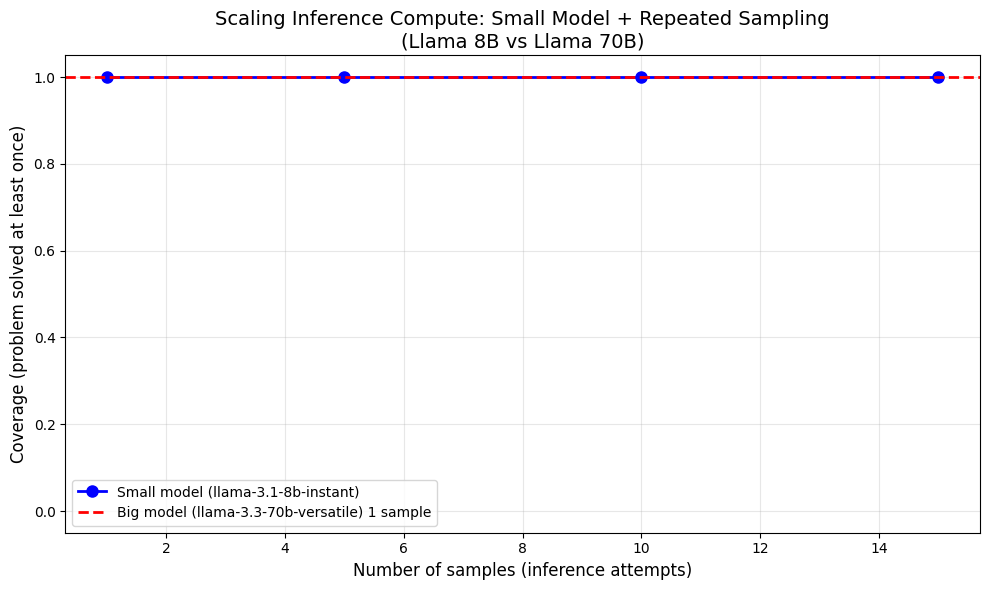

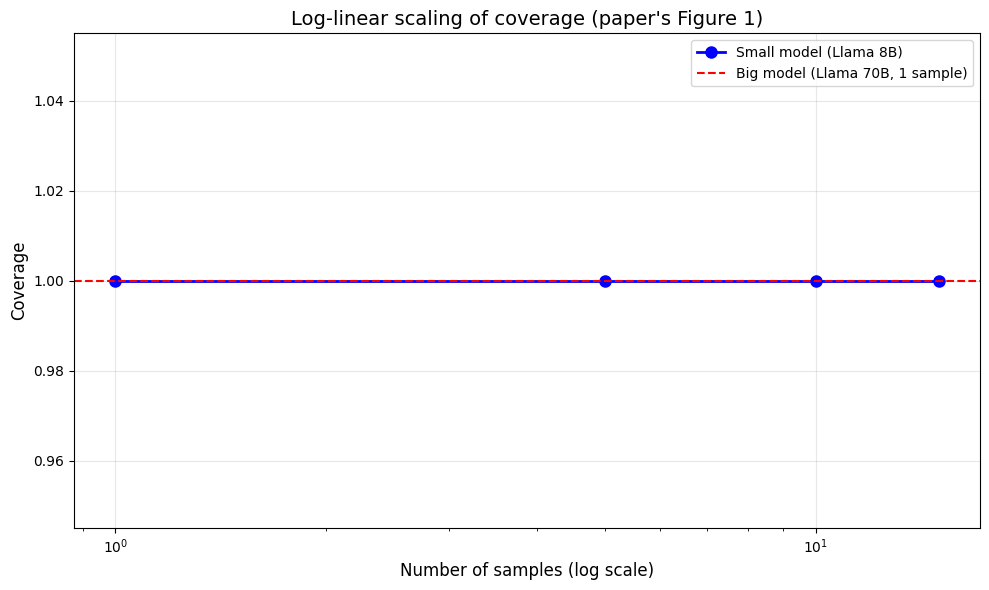

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sample_counts, coverage, 'o-', label=f'Small model ({SMALL_MODEL})', linewidth=2, markersize=8, color='blue')
plt.axhline(y=big_passed, color='red', linestyle='--', label=f'Big model ({BIG_MODEL}) 1 sample', linewidth=2)
plt.xlabel('Number of samples (inference attempts)', fontsize=12)
plt.ylabel('Coverage (problem solved at least once)', fontsize=12)
plt.title('Scaling Inference Compute: Small Model + Repeated Sampling\n(Llama 8B vs Llama 70B)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# Log-linear plot
plt.figure(figsize=(10, 6))
plt.semilogx(sample_counts, coverage, 'o-', label='Small model (Llama 8B)', linewidth=2, markersize=8, color='blue')
plt.axhline(y=big_passed, color='red', linestyle='--', label='Big model (Llama 70B, 1 sample)')
plt.xlabel('Number of samples (log scale)', fontsize=12)
plt.ylabel('Coverage', fontsize=12)
plt.title('Log-linear scaling of coverage (paper\'s Figure 1)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cost / Efficiency Analysis

Groq pricing (approximate):
- Llama 3.3 70B (big): ~$0.59 / 1M input tokens, $0.79 / 1M output tokens
- Llama 3.1 8B (small): ~$0.05 / 1M input tokens, $0.08 / 1M output tokens

In [ ]:
# Approximate token counts per request
prompt_tokens = 300  # ~300 for the prompt
big_completion_tokens = 200  # ~200 for the fix
small_completion_tokens = 200

# Pricing per million tokens (check Groq's latest rates)
big_input_price = 0.59
big_output_price = 0.79
small_input_price = 0.05
small_output_price = 0.08

def cost(model_type, num_samples):
    if model_type == 'big':
        input_cost = prompt_tokens * big_input_price / 1e6
        output_cost = big_completion_tokens * big_output_price / 1e6
    else:
        input_cost = prompt_tokens * small_input_price / 1e6
        output_cost = small_completion_tokens * small_output_price / 1e6
    return (input_cost + output_cost) * num_samples

big_cost = cost('big', 1)
print(f"{'Model':<20} {'Samples':<10} {'Cost':<12} {'Coverage':<10}")
print("-" * 55)
print(f"{'Big (70B)':<20} {'1':<10} ${big_cost:.5f}      {big_passed}")
for n, cov in zip(sample_counts, coverage):
    small_cost = cost('small', n)
    print(f"{'Small (8B)':<20} {n:<10} ${small_cost:.5f}      {cov}")

# Find the point where small model matches or exceeds big model
if any(coverage):
    first_cov_idx = next(i for i, cov in enumerate(coverage) if cov)
    samples_needed = sample_counts[first_cov_idx]
    small_cost_at_match = cost('small', samples_needed)
    print(f"\n📊 Small model matches/exceeds big model at {samples_needed} samples (${small_cost_at_match:.5f})")
    if small_cost_at_match <= big_cost:
        print("   ✅ Small model is CHEAPER than big model at this point!")
    else:
        print(f"   ⚠️ Small model costs more (${small_cost_at_match:.5f} vs ${big_cost:.5f})")
else:
    print("\n⚠️ Small model never succeeded - try increasing temperature or sample count")

Model                Samples    Cost         Coverage  
-------------------------------------------------------
Big (70B)            1          $0.00034      True
Small (8B)           1          $0.00003      True
Small (8B)           5          $0.00015      True
Small (8B)           10         $0.00031      True
Small (8B)           15         $0.00047      True

📊 Small model matches/exceeds big model at 1 samples ($0.00003)
   ✅ Small model is CHEAPER than big model at this point!


## 8. Success Analysis

Let's examine what successful fixes look like (if any).

In [ ]:
successful = [(i, fix, msg) for i, (passed, fix, msg) in enumerate(all_results) if passed]

if successful:
    print(f"✅ Found {len(successful)} successful fixes out of {num_total} samples\n")
    for idx, fix, msg in successful[:3]:  # Show first 3
        print(f"{'='*60}")
        print(f"Sample #{idx + 1}:")
        print(f"{msg}")
        print(f"\nCode:\n{fix[:400]}\n")
else:
    print("❌ No successful fixes found.")
    print("\nPossible reasons:")
    print("  1. Temperature too low (try 0.8-1.0)")
    print("  2. Need more samples")
    print("  3. Task too hard for 8B model")
    print("  4. Function extraction failing")
    print("\nLet's examine a failed sample to debug:")

    # Show a sample output
    sample_idx = 0
    passed, fix, msg = all_results[sample_idx]
    print(f"\nSample #{sample_idx + 1}:")
    print(f"Message: {msg}")
    print(f"\nRaw output:\n{fix[:600]}")

✅ Found 3 successful fixes out of 15 samples

Sample #1:
All tests passed!

Code:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while mid - 1 >= 0 and arr[mid-1] == target:
                mid -= 1
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

Sample #11:
All tests passed!

Code:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:  # corrected loop condition
        mid = (lo + hi) // 2
        if arr[mid] == target:
            while mid > 0 and arr[mid - 1] == target:  # find the first occurrence
                mid -= 1
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    

Sample #15:
All tests passed!

Code:
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
    

In [ ]:
print("\nDetailed Successes per Sample Count:")
print("---------------------------------")

for n in sample_counts:
    num_successful_in_n_samples = sum(r[0] for r in all_results[:n])
    percentage = (num_successful_in_n_samples / n) * 100 if n > 0 else 0
    print(f"  First {n:2d} samples: {num_successful_in_n_samples} successes ({percentage:.1f}%) -- Total evaluated: {n}")



Detailed Successes per Sample Count:
---------------------------------
  First  1 samples: 1 successes (100.0%) -- Total evaluated: 1
  First  5 samples: 1 successes (20.0%) -- Total evaluated: 5
  First 10 samples: 1 successes (10.0%) -- Total evaluated: 10
  First 15 samples: 3 successes (20.0%) -- Total evaluated: 15


## 9. Temperature Experiment (Optional)

Run this cell to experiment with different temperature settings for the small model.

In [ ]:
temperatures = [0.0, 0.5, 0.8, 1.0, 1.2]
samples_per_temp = 10

print("🔬 Temperature experiment on small model...")
print(f"{'Temperature':<12} {'Successes':<12} {'Success Rate':<12}")
print("-" * 40)

for temp in temperatures:
    successes = 0
    for _ in range(samples_per_temp):
        fix = generate_fix(BINARY_SEARCH_TASK, SMALL_MODEL, temperature=temp, verbose=False)
        passed, _ = test_function(fix, BINARY_SEARCH_TASK)
        if passed:
            successes += 1
    rate = successes / samples_per_temp
    print(f"{temp:<12} {successes}/{samples_per_temp:<9} {rate*100:.0f}%")
    time.sleep(0.5)

🔬 Temperature experiment on small model...
Temperature  Successes    Success Rate
----------------------------------------
0.0          0/10        0%
0.5          5/10        50%
0.8          6/10        60%
1.0          3/10        30%
1.2          4/10        40%


## 10. Conclusion

**What this experiment demonstrates:**

1. **Big model baseline** - Single sample from Llama 70B may or may not succeed
2. **Small model scaling** - Coverage increases with more samples from Llama 8B
3. **Cost comparison** - Multiple samples from small model can be cheaper than one from big model
4. **Inference scaling** - With enough samples, small model can match or exceed big model's performance

**The paper's key insight:**
> When an automatic verifier (unit tests) exists, generating many samples from a cheaper model is often more cost-effective than using a single sample from an expensive model.

---
**Reference:** Brown, B., et al. (2024). *Large Language Monkeys: Scaling Inference Compute with Repeated Sampling*. arXiv:2407.21787.